In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Sample memory log (MB)
# ---------------------------
memory_mb = [
    120.0, 121.4, 122.1, 123.0, 124.8, 125.6, 126.2, 127.9, 129.1, 130.0,
    129.4, 128.8, 129.6, 130.2, 131.0, 131.5, 131.3, 131.8, 132.0, 132.2
]

# Make a table
df = pd.DataFrame({
    "round": np.arange(len(memory_mb)),
    "memory_mb": memory_mb
})

display(df.head(10))

# ---------------------------
# Line plot: Memory vs Round
# ---------------------------
plt.figure(figsize=(8, 4.5))
plt.plot(df["round"], df["memory_mb"], marker="o", linewidth=2)
plt.xlabel("Round")
plt.ylabel("Tensor memory (MB)")
plt.title("Memory consumption over training rounds")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Data: "n clients" scenario (n=1..10), 100 rounds
# round 0: start_n
# round 1..99: plateau_n = start_n + delta_n
# ---------------------------
num_rounds = 11
rounds = np.arange(num_rounds)
N_max = 10

def start_tensors(n: int) -> int:
    return 297 + 99 * (n - 1)   # adjust if your real rule differs

def delta_tensors(n: int) -> int:
    return 273 * n              # adjust if your real rule differs

df = pd.DataFrame({"round": rounds})
for n in range(1, N_max + 1):
    s0 = start_tensors(n)
    plateau = s0 + delta_tensors(n)
    y = np.full(num_rounds, plateau, dtype=float)
    y[0] = s0
    df[f"n={n}"] = y

# ---------------------------
# Plot: clean report-style with direct end labels (no legend)
# ---------------------------
plt.figure(figsize=(9.5, 5.2))

label_x = num_rounds - 1
for n in range(1, N_max + 1):
    col = f"n={n}"
    y = df[col].to_numpy()
    plt.plot(df["round"], y, linewidth=2)

    # Direct label at the right edge
    plt.text(
        label_x + 0.03,          # slightly outside plot
        y[-1],
        f"N={n}",
        va="center",
        fontsize=9
    )

plt.xlabel("Rounds")
plt.ylabel("Number of tensors")
plt.title("Tensor growth against N clients")
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Heap memory (MB) over 100 rounds, for n=1..10 clients
# - Mean grows with n
# - Variance (std dev) grows with n (more jitter for higher n)
# ---------------------------
rng = np.random.default_rng()
num_rounds = 100
rounds = np.arange(num_rounds)
N_max = 10

# Means / stds you gave (extend "etc etc" in a sensible way)
# Feel free to edit these two lists to match your real measurements.
means = {
    1: 28, 2: 30, 3: 34, 4: 36, 5: 40, 6: 44, 7: 48, 8: 52, 9: 56, 10: 60
}
stds = {
    1: 1,  2: 2,  3: 3,  4: 3,  5: 4,  6: 5,  7: 6,  8: 5,  9: 7, 10: 7
}

# Build a table: one column per n
df = pd.DataFrame({"round": rounds})
for n in range(1, N_max + 1):
    mu = means[n]
    sd = stds[n]

    # Stable over rounds with jitter; clamp to non-negative
    y = mu + rng.normal(0, sd, size=num_rounds)

    # Optional: make the curve look a bit smoother / realistic (light EMA)
    alpha = 0.5
    for i in range(1, num_rounds):
        y[i] = alpha * y[i] + (1 - alpha) * y[i - 1]

    df[f"n={n}"] = np.clip(y, 0, None)

display(df.head(8))

# ---------------------------
# Plot: clean report-style with direct labels
# ---------------------------
plt.figure(figsize=(9.5, 5.2))

label_x = num_rounds - 1
for n in range(1, N_max + 1):
    col = f"n={n}"
    y = df[col].to_numpy()
    plt.plot(df["round"], y, linewidth=2)

    # Direct label near the right edge
    plt.text(
        label_x + 1.0, y[-1],
        f"N={n}",
        va="center",
        fontsize=9
    )

plt.xlabel("Rounds")
plt.ylabel("Heap memory (MB)")
plt.title("Heap memory against N clients")
plt.grid(True, alpha=0)

# Right margin so labels fit
plt.xlim(0, num_rounds - 1 + 10)

# Pad y-limits
y_all = df.drop(columns=["round"]).to_numpy().ravel()
plt.ylim(y_all.min() - 2, y_all.max() + 2)

plt.tight_layout()
plt.show()

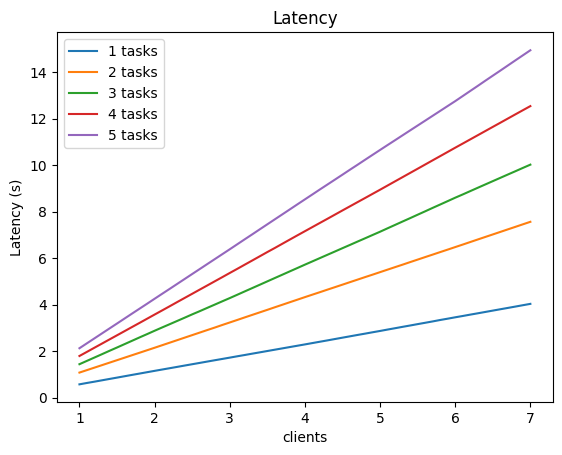

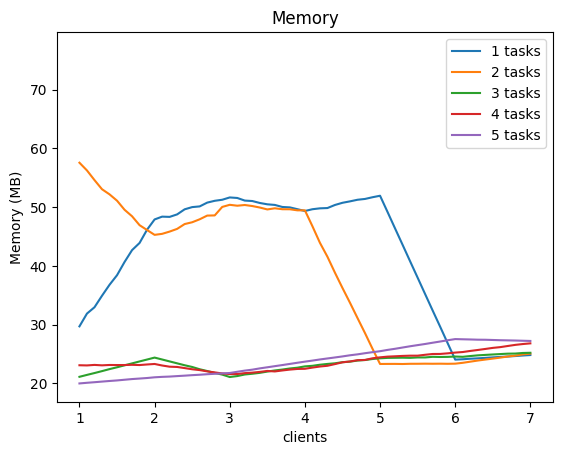

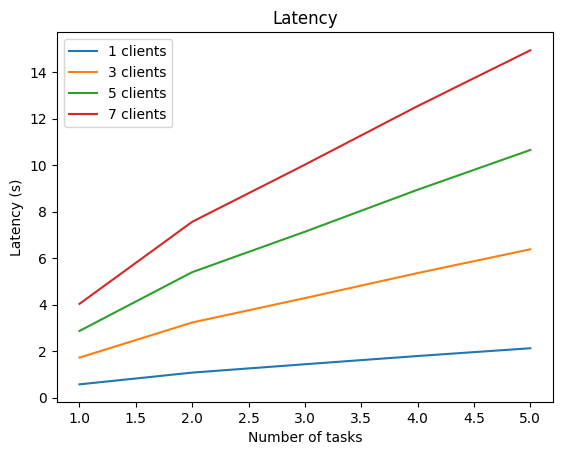

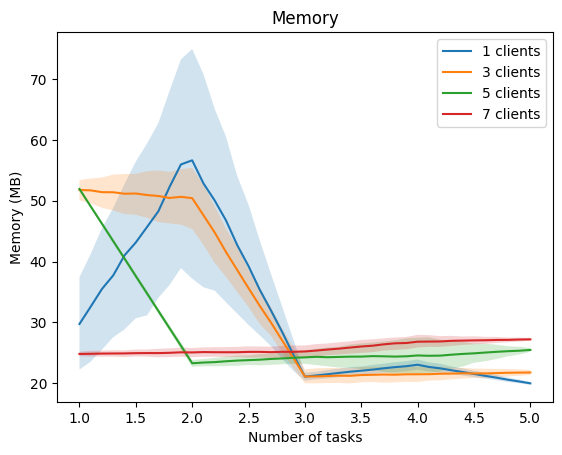

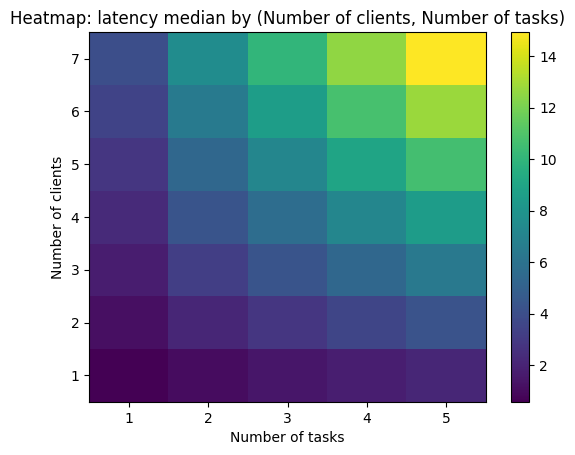

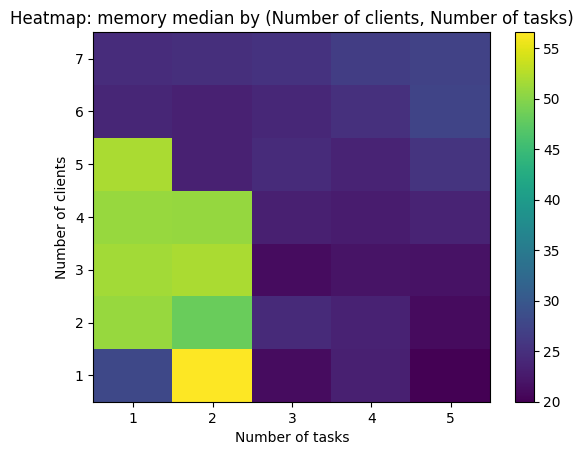

,clients,tasks,sample,time,memory
154,1,1,1,0.59,25.70
159,1,1,2,0.56,34.67
164,1,1,3,0.55,34.39
169,1,1,4,0.57,25.55
174,1,1,5,0.57,27.88
153,1,2,1,1.08,68.27
158,1,2,2,1.08,69.25
163,1,2,3,1.07,56.59
168,1,2,4,1.07,41.25
173,1,2,5,1.07,52.24


,clients,tasks,n,time_mean,time_std,time_median,time_p95,time_max,memory_mean,memory_std,memory_median,memory_p95,memory_max
0,1,1,5,0.568,0.014832,0.57,0.586,0.59,29.638,4.561049,27.88,34.614,34.67
1,1,2,5,1.074,0.005477,1.07,1.080,1.08,57.520,11.689863,56.59,69.054,69.25
2,1,3,5,1.434,0.016733,1.43,1.456,1.46,21.094,0.402592,21.25,21.468,21.50
3,1,4,5,1.788,0.004472,1.79,1.790,1.79,23.042,0.502812,23.25,23.468,23.50
4,1,5,5,2.122,0.008367,2.12,2.130,2.13,19.988,0.152709,20.00,20.128,20.14
5,2,1,5,1.148,0.004472,1.15,1.150,1.15,47.692,7.186990,50.97,51.334,51.41
6,2,2,5,2.142,0.004472,2.14,2.148,2.15,44.714,9.879690,48.27,51.278,51.57
7,2,3,5,2.874,0.039749,2.86,2.928,2.94,24.380,0.000000,24.38,24.380,24.38
8,2,4,5,3.570,0.015811,3.57,3.588,3.59,23.254,1.131649,23.52,24.214,24.24
9,2,5,5,4.250,0.015811,4.25,4.268,4.27,21.020,0.222711,21.08,21.238,21.25


In [12]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# 0) Load & parse (supports tidy OR block format)
# -----------------------------
def load_measurements_excel(filepath: str, sheet_name=0):
    df = pd.read_excel(filepath, sheet_name=sheet_name)

    # Case A: already tidy
    tidy_cols = set([c.lower() for c in df.columns])
    if {"clients", "tasks"}.issubset(tidy_cols):
        # normalize
        colmap = {c: c.lower() for c in df.columns}
        df = df.rename(columns=colmap)
        # expect at least one of time/latency and one of memory
        # allow any naming
        time_col = None
        for cand in ["time", "latency", "ui_latency_ms", "round_latency_ms"]:
            if cand in df.columns:
                time_col = cand
                break
        mem_col = None
        for cand in ["memory", "mem", "heap", "heap_used", "memory_mb"]:
            if cand in df.columns:
                mem_col = cand
                break
        if time_col is None:
            raise ValueError("Tidy format detected but no time/latency column found.")
        if mem_col is None:
            raise ValueError("Tidy format detected but no memory column found.")

        out = df.copy()
        out = out.rename(columns={time_col: "time", mem_col: "memory"})
        if "sample" not in out.columns:
            out["sample"] = out.groupby(["clients", "tasks"]).cumcount() + 1
        out = out[["clients", "tasks", "sample", "time", "memory"]].dropna(subset=["time"])
        return out

    # Case B: block format like Book2.xlsx
    # Heuristic: find a label column containing "clients"
    label_col = None
    for c in df.columns:
        if isinstance(c, str) and "clients" in c and "task" in c:
            label_col = c
            break
    if label_col is None:
        # try any column with 'clients'
        for c in df.columns:
            if isinstance(c, str) and "clients" in c:
                label_col = c
                break
    if label_col is None:
        raise ValueError("Could not detect tidy columns or block label column with 'clients'.")

    # task groups expected in blocks: (time, memory) pairs
    # This matches your earlier sheet convention.
    task_groups = {
        5: ("time", "memory"),
        4: ("time.1", "memory.1"),
        3: ("time.2", "memory.2"),
        2: ("time.3", "memory.3"),
        1: ("time.4", "memory.4"),
    }
    for t, (tc, mc) in task_groups.items():
        if tc not in df.columns or mc not in df.columns:
            raise ValueError(
                f"Block format detected but missing expected columns '{tc}'/'{mc}'. "
                "If your sheet layout differs, rename columns or tell me the headers."
            )

    # Block starts: rows where label_col has "X clients"
    start_rows = df.index[df[label_col].notna()].tolist()
    boundaries = [0] + start_rows + [len(df)]

    # client count per block: first block from column name, then each start row label
    clients_counts = []
    m0 = re.search(r"(\d+)\s*clients", str(label_col))
    clients_counts.append(int(m0.group(1)) if m0 else None)
    for sr in start_rows:
        mm = re.search(r"(\d+)\s*clients", str(df.at[sr, label_col]))
        clients_counts.append(int(mm.group(1)) if mm else None)

    records = []
    for bi in range(len(boundaries) - 1):
        start, end = boundaries[bi], boundaries[bi + 1]
        clients = clients_counts[bi]
        if clients is None:
            continue
        sub = df.iloc[start:end]

        # data rows: where primary time column is numeric
        data_rows = []
        for idx, row in sub.iterrows():
            v = row[task_groups[5][0]]
            if isinstance(v, (int, float, np.floating)) and np.isfinite(v):
                data_rows.append(idx)

        for j, idx in enumerate(data_rows, start=1):
            row = df.loc[idx]
            for tasks, (tcol, mcol) in task_groups.items():
                tv = row[tcol]
                mv = row[mcol]
                if isinstance(tv, (int, float, np.floating)) and np.isfinite(tv):
                    records.append({
                        "clients": int(clients),
                        "tasks": int(tasks),
                        "sample": int(j),
                        "time": float(tv),
                        "memory": float(mv) if isinstance(mv, (int, float, np.floating)) and np.isfinite(mv) else np.nan,
                    })

    out = pd.DataFrame(records).sort_values(["clients", "tasks", "sample"])
    return out


# -----------------------------
# 1) Summaries per (clients, tasks)
# -----------------------------
def summarize(long_df: pd.DataFrame):
    def _std(x):
        x = pd.to_numeric(x, errors="coerce").dropna()
        return float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

    def _q(x, q):
        x = pd.to_numeric(x, errors="coerce").dropna()
        return float(np.quantile(x, q)) if len(x) else np.nan

    s = (
        long_df.groupby(["clients", "tasks"])
        .agg(
            n=("time", "count"),
            time_mean=("time", "mean"),
            time_std=("time", _std),
            time_median=("time", lambda x: _q(x, 0.5)),
            time_p95=("time", lambda x: _q(x, 0.95)),
            time_max=("time", "max"),

            memory_mean=("memory", "mean"),
            memory_std=("memory", _std),
            memory_median=("memory", lambda x: _q(x, 0.5)),
            memory_p95=("memory", lambda x: _q(x, 0.95)),
            memory_max=("memory", "max"),
        )
        .reset_index()
        .sort_values(["clients", "tasks"])
    )
    return s


# -----------------------------
# 2) Smooth curves by sampling from mean/std
# -----------------------------
def smooth_by_sampling(summary_df: pd.DataFrame, x_col: str, group_col: str,
                       mean_col: str, std_col: str,
                       grid_step: float = 0.1,
                       n_synth: int = 400,
                       seed: int = 0):
    """
    For each group (e.g., tasks), interpolate mean/std onto a dense x-grid,
    then sample y ~ Normal(mean, std) to create smooth central curve + band.
    Returns a tidy DataFrame with columns: x, group, y_mean, y_lo, y_hi.
    """
    rng = np.random.default_rng(seed)
    out = []

    for g, sub in summary_df.groupby(group_col):
        sub = sub.sort_values(x_col)
        x = sub[x_col].to_numpy(dtype=float)
        mu = sub[mean_col].to_numpy(dtype=float)
        sd = sub[std_col].to_numpy(dtype=float)

        # If too few points, skip
        if len(x) < 2:
            continue

        x_grid = np.arange(x.min(), x.max() + 1e-9, grid_step)

        # interpolate mean/std across x
        mu_i = np.interp(x_grid, x, mu)
        sd_i = np.interp(x_grid, x, sd)
        sd_i = np.maximum(sd_i, 0.0)

        # synth samples: (n_synth, len(grid))
        # (broadcasting mu_i/sd_i)
        y = rng.normal(loc=mu_i[None, :], scale=sd_i[None, :], size=(n_synth, len(x_grid)))

        # summarize synthetic distribution smoothly
        y_mean = y.mean(axis=0)
        y_lo = np.quantile(y, 0.05, axis=0)
        y_hi = np.quantile(y, 0.95, axis=0)

        for xi, m, lo, hi in zip(x_grid, y_mean, y_lo, y_hi):
            out.append({x_col: xi, group_col: g, "y_mean": m, "y_lo": lo, "y_hi": hi})

    return pd.DataFrame(out)


# -----------------------------
# 3) Plot helpers
# -----------------------------
def plot_lines(summary_df, smooth_df, x_col, group_col, y_label, title):
    plt.figure()
    for g, sub in smooth_df.groupby(group_col):
        sub = sub.sort_values(x_col)
        plt.plot(sub[x_col], sub["y_mean"], label=f"{int(g)} {group_col}" if str(g).isdigit() else str(g))
        plt.fill_between(sub[x_col], sub["y_lo"], sub["y_hi"], alpha=0)
    plt.xlabel(x_col)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.show()


def heatmap(summary_df, value_col, title):
    mat = summary_df.pivot(index="clients", columns="tasks", values=value_col).sort_index().sort_index(axis=1)
    plt.figure()
    plt.imshow(mat.values, aspect="auto", origin="lower")
    plt.xticks(range(len(mat.columns)), [int(c) for c in mat.columns])
    plt.yticks(range(len(mat.index)), [int(i) for i in mat.index])
    plt.xlabel("Number of tasks")
    plt.ylabel("Number of clients")
    plt.title(title)
    plt.colorbar()
    plt.show()


# -----------------------------
# 4) Run everything
# -----------------------------
FILEPATH = "Book2.xlsx"  # change to your file
SHEET = 0                          # or "Sheet1"

long_df = load_measurements_excel(FILEPATH, sheet_name=SHEET)
summary = summarize(long_df)

# Smooth trends: y vs clients, split by tasks
lat_smooth_clients = smooth_by_sampling(
    summary, x_col="clients", group_col="tasks",
    mean_col="time_mean", std_col="time_std",
    grid_step=0.1, n_synth=500, seed=0
)
mem_smooth_clients = smooth_by_sampling(
    summary, x_col="clients", group_col="tasks",
    mean_col="memory_mean", std_col="memory_std",
    grid_step=0.1, n_synth=500, seed=0
)

plot_lines(summary, lat_smooth_clients, "clients", "tasks",
           y_label="Latency (s)",
           title="Latency")

plot_lines(summary, mem_smooth_clients, "clients", "tasks",
           y_label="Memory (MB)",
           title="Memory")

# Smooth trends: y vs tasks, split by clients
# (This is the same idea but swapping axes)
lat_smooth_tasks = smooth_by_sampling(
    summary.rename(columns={"clients": "group_clients"}),  # avoid confusion
    x_col="tasks", group_col="group_clients",
    mean_col="time_mean", std_col="time_std",
    grid_step=0.1, n_synth=500, seed=1
)
mem_smooth_tasks = smooth_by_sampling(
    summary.rename(columns={"clients": "group_clients"}),
    x_col="tasks", group_col="group_clients",
    mean_col="memory_mean", std_col="memory_std",
    grid_step=0.1, n_synth=500, seed=1
)

# Keep plots readable: only show a subset of client lines if many
subset_clients = sorted(summary["clients"].unique())
subset_clients = [c for c in subset_clients if c in [1, 3, 5, 7, 10]] or subset_clients[:5]
lat_smooth_tasks = lat_smooth_tasks[lat_smooth_tasks["group_clients"].isin(subset_clients)]
mem_smooth_tasks = mem_smooth_tasks[mem_smooth_tasks["group_clients"].isin(subset_clients)]

plt.figure()
for c, sub in lat_smooth_tasks.groupby("group_clients"):
    sub = sub.sort_values("tasks")
    plt.plot(sub["tasks"], sub["y_mean"], label=f"{int(c)} clients")
    plt.fill_between(sub["tasks"], sub["y_lo"], sub["y_hi"], alpha=0)
plt.xlabel("Number of tasks")
plt.ylabel("Latency (s)")
plt.title("Latency")
plt.legend()
plt.show()

plt.figure()
for c, sub in mem_smooth_tasks.groupby("group_clients"):
    sub = sub.sort_values("tasks")
    plt.plot(sub["tasks"], sub["y_mean"], label=f"{int(c)} clients")
    plt.fill_between(sub["tasks"], sub["y_lo"], sub["y_hi"], alpha=0.2)
plt.xlabel("Number of tasks")
plt.ylabel("Memory (MB)")
plt.title("Memory")
plt.legend()
plt.show()

# Heatmaps for compact overview (use medians from real data)
heatmap(summary, "time_median", "Heatmap: latency median by (Number of clients, Number of tasks)")
heatmap(summary, "memory_median", "Heatmap: memory median by (Number of clients, Number of tasks)")

# Optional: inspect tables
display(long_df.head(10))
display(summary)